# Linear dataset generation -- walkthrough

Tests the three coefficient structures, observation noise, and structural
error for `data_generator_funs`. Each section generates data, checks the
structure is actually what it claims to be, and plots it.

In [3]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np

from data_generator_funs.dataset import generate_linear_dataset, add_observation_noise, add_structural_error
from data_generator_funs import linear
from utils.plotting import plot_correlation, plot_data_overview, plot_scatter_examples, plot_block_structure
from data_generator_funs.netcdf_io import save_dataset_folder

summary_lines = []

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Structure 3b -- OVERLAPPING param groups

`param_group_sizes` cuts the params into disjoint groups, so each param is a
strong driver of exactly one output group. Passing `param_groups` instead --
explicit index lists that may share params -- lets one param be a strong driver
of **several** output groups. `linear.sliding_param_groups(n_groups, group_size,
stride)` builds the sliding case: with `stride < group_size` consecutive groups
overlap.

Here groups are `[[0,1,2,3], [2,3,4,5], [4,5,6,7]]`, so x2/x3 are strong on
output groups 0 **and** 1, and x4/x5 on groups 1 **and** 2. The strong / small /
zero rule is applied per parameter: being in group `h` wins, an earlier group
only gives the small background, and only-later groups stay exactly zero.

param_groups: [[0, 1, 2], [2, 3, 4], [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]]
params driving more than one output group: [2 4] -> groups [[0, 1], [1, 2]]
mean |coeff| strong (param in that output's group): 3.017
mean |coeff| small  (param in an earlier group):    0.331
max  |coeff| zero   (param in later groups only):   0.000


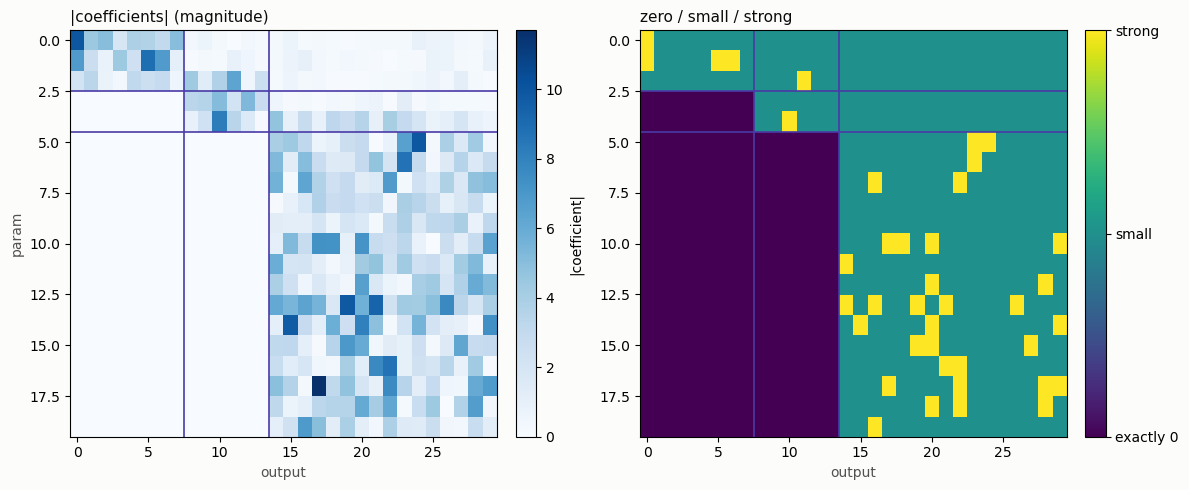

In [86]:
#overlap_groups = linear.sliding_param_groups(n_groups=3, group_size=4, stride=2)
overlap_groups = [[0, 1, 2], [2, 3,4], [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]]
print("param_groups:", overlap_groups)
output_path = "/glade/u/home/qingyuany/repos/cliffnotes/datasets/ds_Sep2_2026/"
file_name = "linear_obserr_scale00"

ds_ov = generate_linear_dataset(
    n_samples=300, n_params=20, n_outputs=30, structure="block_triangular",
    structure_kwargs=dict(
        param_groups=overlap_groups,          # instead of param_group_sizes
        output_group_sizes=[8, 6, 16],
        sensitivity_scale=4.0,
        background_scale=0.5,
    ),
    seed=1,
)
C_ov = ds_ov["model_params"]["coefficients"]
mem = ds_ov["param_group_membership"]   # (n_params, n_groups) 0/1 -- the real group map
og_ov = ds_ov["output_group_id"]

save_dataset_folder(ds_ov, output_path , filename_base=file_name)



shared = np.flatnonzero(mem.sum(axis=1) > 1)
print("params driving more than one output group:", shared,
      "-> groups", [list(np.flatnonzero(mem[i])) for i in shared])

# Classify every coefficient with membership, NOT param_group_id: under overlap
# a single group id per param can no longer tell strong from background.
strong_mag, small_mag, zero_mag = [], [], []
for i in range(mem.shape[0]):
    for j in range(len(og_ov)):
        h, val = og_ov[j], abs(C_ov[i, j])
        if mem[i, h]:
            strong_mag.append(val)
        elif mem[i, :h].any():
            small_mag.append(val)
        else:
            zero_mag.append(val)

print(f"mean |coeff| strong (param in that output's group): {np.mean(strong_mag):.3f}")
print(f"mean |coeff| small  (param in an earlier group):    {np.mean(small_mag):.3f}")
print(f"max  |coeff| zero   (param in later groups only):   {np.max(zero_mag):.3f}")

_ = plot_block_structure(ds_ov)

summary_lines.append(
    f"Structure 'block_triangular' with overlapping param groups {overlap_groups}: "
    f"params {list(shared)} are strong on two output groups each; "
    f"strong mean |coeff|={np.mean(strong_mag):.2f}, background mean={np.mean(small_mag):.2f}, "
    f"lower-left max={np.max(zero_mag):.2f} (exactly zero)."
)

In [87]:
ds_ov["X"] @ ds_ov["model_params"]["coefficients"] - ds_ov["Y"]


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [88]:
ds_ov["Y"].std(axis = 0)

array([ 6.95559339,  3.50792674,  2.91970609,  2.72416776,  3.12319102,
        5.66560254,  4.53463285,  2.92332483,  3.26722329,  2.65988624,
        5.885937  ,  4.22415086,  3.23642297,  2.0759185 ,  8.84643448,
        8.59946632,  8.34940649,  9.91038877,  7.06166664,  9.07462606,
       10.11874635,  8.80737988,  9.86446022,  8.6844461 ,  8.56539176,
        6.12612161,  6.89564436,  6.76855909,  9.27352309,  8.6259395 ])

In [89]:
ds_ov["x_true"] @ ds_ov["model_params"]["coefficients"] - ds_ov["y_true"]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [90]:
ds_ov["X"] @ ds_ov["model_params"]["coefficients"] - ds_ov["Y"]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

## Observation noise

`add_observation_noise` adds i.i.d. N(0, noise_std) measurement noise to a
"true" observation. A correctly-specified model can average this out given
enough data -- it's not structural.

In [91]:
#overlap_groups = linear.sliding_param_groups(n_groups=3, group_size=4, stride=2)
overlap_groups = [[0, 1, 2], [2, 3,4], [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]]
print("param_groups:", overlap_groups)
output_path = "/glade/u/home/qingyuany/repos/cliffnotes/datasets/ds_Sep2_2026/"
file_name = "linear_obserr_scale02"
noise_std = 0.2

ds_ov = generate_linear_dataset(
    n_samples=300, n_params=20, n_outputs=30, structure="block_triangular",
    structure_kwargs=dict(
        param_groups=overlap_groups,          # instead of param_group_sizes
        output_group_sizes=[8, 6, 16],
        sensitivity_scale=4.0,
        background_scale=0.5,
    ),
    seed=2,
    noise_std = noise_std,
)
C_ov = ds_ov["model_params"]["coefficients"]
mem = ds_ov["param_group_membership"]   # (n_params, n_groups) 0/1 -- the real group map
og_ov = ds_ov["output_group_id"]

save_dataset_folder(ds_ov, output_path, filename_base=file_name)

param_groups: [[0, 1, 2], [2, 3, 4], [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]]


<xarray.Dataset> Size: 126kB
Dimensions:                 (sample: 300, input_feature: 20,
                             output_feature: 30, param_group_membership_col: 3)
Dimensions without coordinates: sample, input_feature, output_feature,
                                param_group_membership_col
Data variables:
    X                       (sample, input_feature) float64 48kB 0.8716 ... 0...
    Y                       (sample, output_feature) float64 72kB 0.4228 ... ...
    x_true                  (input_feature) float64 160B 0.5289 ... 0.8014
    y_true                  (output_feature) float64 240B 4.513 -4.193 ... 2.83
    coefficients            (input_feature, output_feature) float64 5kB 1.171...
    param_group_id          (input_feature) int64 160B 0 0 0 1 1 2 ... 2 2 2 2 2
    output_group_id         (output_feature) int64 240B 0 0 0 0 0 ... 2 2 2 2 2
    param_group_membership  (input_feature, param_group_membership_col) int64 480B ...
Attributes: (12/14)
    summary:         Synthetic parameter-estimation dataset generated by data...
    model:           linear
    model_kwargs:    {"structure": "block_triangular", "structure_kwargs": {"...
    param_names:     ["coefficients"]
    param_low:       -1.0
    param_high:      1.0
    ...              ...
    n_outputs:       30
    noise_std:       0.2
    structural_idx:  []
    n_structural:    0
    seed:            2
    metadata_json:   {"model": "linear", "model_kwargs": {"structure": "block...

### Structural error on this same overlapping-group model

**How to ask for it:** add `structural_idx=[...]` to the exact same
`generate_linear_dataset(...)` call. Nothing else changes.

**What the generator does with it** (`add_structural_error`, dataset.py):

1. draws a *second, wrong* input `x_b` from the same parameter range,
2. computes what that wrong input would have produced, `y_b = x_b @ A`,
3. copies `y_b`'s values into `y_true` **only at the listed output indices**.

The untouched outputs still need `x_true`; the spliced ones now need `x_b`.
Since `x_b != x_true`, **no single parameter vector reproduces the whole
observation**. That is the difference from observation noise: noise is
zero-mean and averages away with more data, this does not shrink no matter how
many samples you collect. Indices are **0-based**, matching the `y0..y29`
column names in the saved CSVs.

**Why we do two placements.** The output groups here are
`[8, 6, 16]`, so `y0..y7` = group 0, `y8..y13` = group 1, `y14..y29` = group 2.
The two cases corrupt the same *number* of outputs (2) in very different
places:

| case | corrupted | output group | that group's structure |
|---|---|---|---|
| A | `y1`, `y3` | 0 | 8 outputs driven by only 3 params (`x0,x1,x2`) |
| B | `y20`, `y25` | 2 | 16 outputs driven by 16 params (`x4..x19`) |

Group 0 is massively **over**-determined -- 8 equations for 3 unknowns -- so a
least-squares fit has no spare freedom to bend toward the corrupted values; the
conflict is forced out into the residual where you can *see* it. Group 2 has 16
equations for 16 unknowns, so the fit can quietly absorb the corruption by
moving parameters instead. Watch for the counter-intuitive result below: the
case with the **smaller** residual is the one that damages the parameters
**more**. A small residual is not evidence that your calibration worked.

In [92]:
# Two structural-error cases on the SAME model as the cell above (same seed =>
# identical coefficients, X, Y and x_true; even the same wrong input x_b). The
# only thing that changes is WHICH outputs get the wrong model's values.
# Indices are 0-based, matching the y0..y29 column names in the saved CSVs.
struct_cases = {
    "linear_obserr_scale00_strerr_y1_y3":   [1, 3],    # both land in output group 0
    "linear_obserr_scale00_strerr_y20_y25_y29": [20, 25, 29],  # both land in output group 2
}

base = dict(
    n_samples=300, n_params=20, n_outputs=30, structure="block_triangular",
    structure_kwargs=dict(
        param_groups=overlap_groups,
        output_group_sizes=[8, 6, 16],
        sensitivity_scale=4.0,
        background_scale=0.5,
    ),
    seed=3,
    noise_std=0,
)

A = ds_ov["model_params"]["coefficients"]      # ds_ov = the noise-only baseline above
og = ds_ov["output_group_id"]
y_clean = ds_ov["y_true"]

def best_fit(y):
    """The single best parameter vector for observation y, given y ~ x @ A.
    Returns x_hat and how much of the observation it still cannot explain."""
    x_hat, *_ = np.linalg.lstsq(A.T, y, rcond=None)
    return x_hat, np.linalg.norm(y - x_hat @ A)

x_hat0, resid0 = best_fit(y_clean)
err0 = np.abs(x_hat0 - ds_ov["x_true"]).max()
print("output group of each y index:", og)
print(f"baseline, noise only: unexplained residual {resid0:.3f}, worst param error {err0:.3f}\n")

ds_struct = {}
for name, idx in struct_cases.items():
    ds = generate_linear_dataset(structural_idx=idx, **base)
    save_dataset_folder(ds, output_path, filename_base=name)
    ds_struct[name] = ds

    # Where the observation moved: ONLY the corrupted outputs should differ from
    # the noise-only baseline, because every other random stream is shared.
    delta = ds["y_true"] - y_clean
    x_hat, resid = best_fit(ds["y_true"])
    err = np.abs(x_hat - ds["x_true"])

    print(f"--- {name}: structural_idx={idx}, output groups {og[idx]} ---")
    print(f"  y_true shifted by {np.round(delta[idx], 2)} at those outputs, "
          f"max shift elsewhere {np.abs(np.delete(delta, idx)).max():.3f}")
    print(f"  unexplained residual {resid:.3f}  (baseline {resid0:.3f})")
    print(f"  worst param error    {err.max():.3f}  (baseline {err0:.3f}) "
          f"at param x{int(np.argmax(err))}")
    print()

summary_lines.append(
    "Structural error on the overlapping-group model, two placements: "
    f"y1/y3 (output group 0) pushes the best-fit residual to "
    f"{best_fit(ds_struct['linear_obserr_scale00_strerr_y1_y3']['y_true'])[1]:.2f} but barely biases the "
    f"params; y20/y25 (output group 2) hides better in the residual yet biases the worst param "
    f"far more -- placement matters more than count."
)

output group of each y index: [0 0 0 0 0 0 0 0 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
baseline, noise only: unexplained residual 0.701, worst param error 0.072

--- linear_obserr_scale00_strerr_y1_y3: structural_idx=[1, 3], output groups [0 0] ---
  y_true shifted by [4.36 9.55] at those outputs, max shift elsewhere 18.830
  unexplained residual 18.045  (baseline 0.701)
  worst param error    7.574  (baseline 0.072) at param x16

--- linear_obserr_scale00_strerr_y20_y25_y29: structural_idx=[20, 25, 29], output groups [2 2 2] ---
  y_true shifted by [-10.04 -22.28   2.03] at those outputs, max shift elsewhere 18.830
  unexplained residual 16.653  (baseline 0.701)
  worst param error    7.210  (baseline 0.072) at param x16



In [93]:
# Two structural-error cases on the SAME model as the cell above (same seed =>
# identical coefficients, X, Y and x_true; even the same wrong input x_b). The
# only thing that changes is WHICH outputs get the wrong model's values.
# Indices are 0-based, matching the y0..y29 column names in the saved CSVs.
struct_cases = {
    "linear_obserr_scale02_strerr_y1_y3":   [1, 3],    # both land in output group 0
    "linear_obserr_scale02_strerr_y20_y25_y29": [20, 25, 29],  # both land in output group 2
}
noise_std = 0.2
base = dict(
    n_samples=300, n_params=20, n_outputs=30, structure="block_triangular",
    structure_kwargs=dict(
        param_groups=overlap_groups,
        output_group_sizes=[8, 6, 16],
        sensitivity_scale=4.0,
        background_scale=0.5,
    ),
    seed=4,
    noise_std=noise_std,
)

A = ds_ov["model_params"]["coefficients"]      # ds_ov = the noise-only baseline above
og = ds_ov["output_group_id"]
y_clean = ds_ov["y_true"]

def best_fit(y):
    """The single best parameter vector for observation y, given y ~ x @ A.
    Returns x_hat and how much of the observation it still cannot explain."""
    x_hat, *_ = np.linalg.lstsq(A.T, y, rcond=None)
    return x_hat, np.linalg.norm(y - x_hat @ A)

x_hat0, resid0 = best_fit(y_clean)
err0 = np.abs(x_hat0 - ds_ov["x_true"]).max()
print("output group of each y index:", og)
print(f"baseline, noise only: unexplained residual {resid0:.3f}, worst param error {err0:.3f}\n")

ds_struct = {}
for name, idx in struct_cases.items():
    ds = generate_linear_dataset(structural_idx=idx, **base)
    save_dataset_folder(ds, output_path, filename_base=name)
    ds_struct[name] = ds

    # Where the observation moved: ONLY the corrupted outputs should differ from
    # the noise-only baseline, because every other random stream is shared.
    delta = ds["y_true"] - y_clean
    x_hat, resid = best_fit(ds["y_true"])
    err = np.abs(x_hat - ds["x_true"])

    print(f"--- {name}: structural_idx={idx}, output groups {og[idx]} ---")
    print(f"  y_true shifted by {np.round(delta[idx], 2)} at those outputs, "
          f"max shift elsewhere {np.abs(np.delete(delta, idx)).max():.3f}")
    print(f"  unexplained residual {resid:.3f}  (baseline {resid0:.3f})")
    print(f"  worst param error    {err.max():.3f}  (baseline {err0:.3f}) "
          f"at param x{int(np.argmax(err))}")
    print()

summary_lines.append(
    "Structural error on the overlapping-group model, two placements: "
    f"y1/y3 (output group 0) pushes the best-fit residual to "
    f"{best_fit(ds_struct['linear_obserr_scale02_strerr_y1_y3']['y_true'])[1]:.2f} but barely biases the "
    f"params; y20/y25 (output group 2) hides better in the residual yet biases the worst param "
    f"far more -- placement matters more than count."
)

output group of each y index: [0 0 0 0 0 0 0 0 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
baseline, noise only: unexplained residual 0.701, worst param error 0.072

--- linear_obserr_scale02_strerr_y1_y3: structural_idx=[1, 3], output groups [0 0] ---
  y_true shifted by [4.56 8.98] at those outputs, max shift elsewhere 30.345
  unexplained residual 11.774  (baseline 0.701)
  worst param error    2.004  (baseline 0.072) at param x18

--- linear_obserr_scale02_strerr_y20_y25_y29: structural_idx=[20, 25, 29], output groups [2 2 2] ---
  y_true shifted by [  7.17 -18.14   6.05] at those outputs, max shift elsewhere 30.345
  unexplained residual 8.604  (baseline 0.701)
  worst param error    1.652  (baseline 0.072) at param x18



In [94]:
import xarray as xr
import os
file_loc = "/glade/u/home/qingyuany/repos/cliffnotes/datasets/ds_Sep2_2026"


In [95]:
ds1 = xr.open_dataset(os.path.join(file_loc, "linear_obserr_scale00", "linear_obserr_scale00.nc"))
ds2 = xr.open_dataset(os.path.join(file_loc, "linear_obserr_scale02", "linear_obserr_scale02.nc"))
ds3 = xr.open_dataset(os.path.join(file_loc, "linear_obserr_scale00_strerr_y1_y3", "linear_obserr_scale00_strerr_y1_y3.nc"))
ds4 = xr.open_dataset(os.path.join(file_loc, "linear_obserr_scale00_strerr_y20_y25_y29", "linear_obserr_scale00_strerr_y20_y25_y29.nc"))
ds5 = xr.open_dataset(os.path.join(file_loc, "linear_obserr_scale02_strerr_y1_y3", "linear_obserr_scale02_strerr_y1_y3.nc"))
ds6 = xr.open_dataset(os.path.join(file_loc, "linear_obserr_scale02_strerr_y20_y25_y29", "linear_obserr_scale02_strerr_y20_y25_y29.nc"))


In [143]:
ds3

<xarray.Dataset> Size: 126kB
Dimensions:                 (sample: 300, input_feature: 20,
                             output_feature: 30, param_group_membership_col: 3)
Dimensions without coordinates: sample, input_feature, output_feature,
                                param_group_membership_col
Data variables:
    X                       (sample, input_feature) float64 48kB ...
    Y                       (sample, output_feature) float64 72kB ...
    x_true                  (input_feature) float64 160B -0.2783 ... 0.4455
    y_true                  (output_feature) float64 240B ...
    coefficients            (input_feature, output_feature) float64 5kB ...
    param_group_id          (input_feature) int64 160B ...
    output_group_id         (output_feature) int64 240B ...
    param_group_membership  (input_feature, param_group_membership_col) int64 480B ...
    x_b                     (input_feature) float64 160B ...
    y_b                     (output_feature) float64 240B ...
Attributes: (12/14)
    summary:         Synthetic parameter-estimation dataset generated by data...
    model:           linear
    model_kwargs:    {"structure": "block_triangular", "structure_kwargs": {"...
    param_names:     ["coefficients"]
    param_low:       -1.0
    param_high:      1.0
    ...              ...
    n_outputs:       30
    noise_std:       0
    structural_idx:  [1 3]
    n_structural:    2
    seed:            3
    metadata_json:   {"model": "linear", "model_kwargs": {"structure": "block...

In [151]:
ds_test = ds1



    

In [155]:
ds1.coefficients - ds5.coefficients


<xarray.DataArray 'coefficients' (input_feature: 20, output_feature: 30)> Size: 5kB
array([[ 1.26791178e+01, -1.61766132e-01, -7.87955844e+00,
         8.46316881e+00,  2.43699445e+00,  3.56884846e+00,
         1.48738329e+00,  2.28976218e-01,  1.06068365e+00,
         1.43040824e-01, -2.50028905e-01,  1.36842145e-01,
         9.26126916e-02, -8.54211676e-01, -5.29102426e-01,
        -5.80120284e-01,  3.17978820e-01, -4.57957418e-02,
        -2.27298518e-01,  1.76989033e-02,  3.77828470e-01,
        -3.25823760e-01, -9.16516431e-01,  9.60466054e-01,
         9.58614364e-01, -3.84442700e-01, -2.94188527e-01,
        -4.91952967e-01,  1.16284197e+00,  1.07909695e+00],
       [ 1.27374454e+01, -9.39207742e-01, -4.04063214e+00,
        -2.45898630e+00, -1.03132133e+01, -7.76913322e+00,
        -1.83944582e+00,  2.53802134e+00, -4.73530875e-01,
         8.79426240e-02, -1.11581205e-02,  3.64950695e-01,
        -7.84420890e-01,  4.27964424e-01,  8.53913378e-01,
         5.29587977e-01, -1.73048156e+00,  1.34241155e-01,
        -9.23319514e-01,  7.97511461e-01,  2.92410443e-03,
        -2.49464053e-01, -9.62534139e-01, -7.54530019e-03,
        -5.87953382e-01,  1.31982069e+00,  6.02788036e-01,
        -1.49488831e+00,  9.24203534e-01, -1.07219937e+00],
...
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -5.99416919e+00,
        -2.30757085e+00, -3.84965155e+00, -8.92325322e+00,
         4.36047533e+00,  1.85855577e+00,  4.00788535e+00,
        -9.76860547e+00, -9.49347050e+00,  6.81816064e-01,
         2.86061084e+00,  4.87458338e+00, -7.98013563e-01,
         5.57579601e+00, -1.17646204e+01,  4.69104961e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  1.77932534e+00,
         5.74327546e-02, -5.23650786e+00,  4.06765471e-01,
         9.56923395e-01, -4.27943134e+00, -7.14488100e+00,
         7.60238621e+00,  3.94911024e+00,  6.87925834e+00,
        -4.65775375e+00, -8.53458745e+00,  2.91230698e+00,
         4.71413338e-01,  1.10064830e+00,  2.47696623e+00]])
Dimensions without coordinates: input_feature, output_feature